X shape: (6000, 32, 32, 1)
y shape: (6000, 6)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,094 (66.77 KB)

 Trainable params: 17,094 (66.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1700 - loss: 1.7942
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1665 - loss: 1.7932
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1710 - loss: 1.7924
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1732 - loss: 1.7920
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1758 - loss: 1.7919
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1772 - loss: 1.7912
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1805 - loss: 1.7910
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.1770 - loss: 1.7899
Epoch 9/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1775 - loss: 1.7897
Epoch 10/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1795 - loss: 1.7899


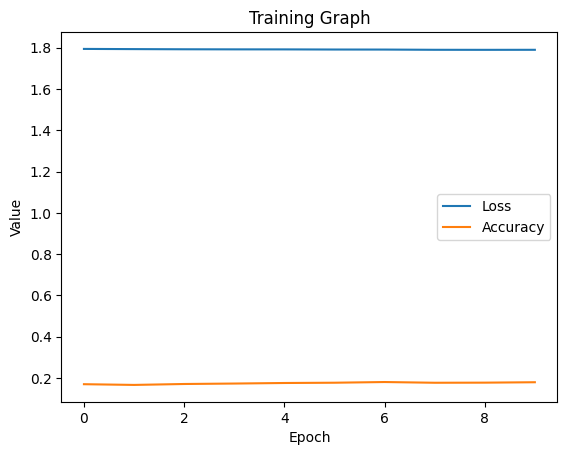

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step

Predicted Class: 0


In [ ]:
# Q. Design and implement a CNN for grayscale image
# classification with the following specifications:
#
# Input Image Size:
#   1 × 32 × 32
#
# CNN Architecture:
#   - Conv Layer 1:
#       16 filters, 3×3 kernel,
#       stride = 1, padding = 1
#
#   - MaxPooling:
#       2×2, stride = 2
#
#   - Conv Layer 2:
#       32 filters, 3×3 kernel,
#       stride = 1, padding = 1
#
#   - MaxPooling:
#       2×2, stride = 2
#
#   - Fully Connected Layer:
#       Output = 6 classes
#
# Activation:
#   ReLU
#
# Output:
#   Softmax probabilities
#
# (a) Draw the CNN architecture and compute output shapes
#     after every layer.
#
# (b) Specify shapes of all parameters and activations.
#
# (c) Generate a synthetic dataset of 6000 grayscale images
#     using NumPy.
#
# (d) Implement the CNN using TensorFlow/Keras.
#
# (e) Train the network using Batch Gradient Descent:
#       - Cross Entropy Loss
#       - Learning Rate = 0.005
#       - Epochs = 10


import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

from tensorflow.keras.utils import to_categorical


# (a) Output Shape Calculation

# Input:
# (1, 32, 32)

# Conv1:
# ((32 - 3 + 2*1)/1) + 1 = 32
# Output:
# (16, 32, 32)

# MaxPool1:
# 32 / 2 = 16
# Output:
# (16, 16, 16)

# Conv2:
# ((16 - 3 + 2*1)/1) + 1 = 16
# Output:
# (32, 16, 16)

# MaxPool2:
# 16 / 2 = 8
# Output:
# (32, 8, 8)

# Flatten:
# 32 × 8 × 8 = 2048

# Fully Connected:
# 2048 → 6


# (b) Parameter Shapes

# W1 = (16, 1, 3, 3)
# b1 = (16)

# W2 = (32, 16, 3, 3)
# b2 = (32)

# W3 = (2048, 6)
# b3 = (6)


# (c) Generate Synthetic Dataset using NumPy

# 6000 grayscale images
# Shape = (6000, 32, 32, 1)
X = np.random.rand(6000, 32, 32, 1).astype(np.float32)
y = np.random.randint( 0, 6, size=(6000,))

y = to_categorical(y, num_classes=6)

print("X shape:", X.shape)
print("y shape:", y.shape)


# (d) CNN Implementation using TensorFlow/Keras

model = Sequential([

    # Conv Layer 1
    Conv2D(
        filters=16,
        kernel_size=(3,3),
        strides=1,
        padding='same',
        activation='relu',
        input_shape=(32,32,1)
    ),

    # MaxPooling Layer 1
    MaxPooling2D(
        pool_size=(2,2),
        strides=2
    ),

    # Conv Layer 2
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=1,
        padding='same',
        activation='relu'
    ),

    # MaxPooling Layer 2
    MaxPooling2D(
        pool_size=(2,2),
        strides=2
    ),

    Flatten(),

    Dense(
        units=6,
        activation='softmax'
    )
])


model.summary()


# (e) Compile and Train the Model

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.005
    ),

    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train the Model

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32
)


# Plot Training Graph

plt.plot(history.history['loss'])
plt.plot(history.history['accuracy'])

plt.title("Training Graph")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.legend([
    "Loss",
    "Accuracy"
])

plt.show()


# Test on One Random Sample

sample = np.random.rand(
    1, 32, 32, 1
).astype(np.float32)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

print("\nPredicted Class:",
      predicted_class)

In [4]:
history.history

{'accuracy': [0.17000000178813934,
  0.1665000021457672,
  0.17100000381469727,
  0.1731666624546051,
  0.1758333295583725,
  0.1771666705608368,
  0.18050000071525574,
  0.1770000010728836,
  0.17749999463558197,
  0.17949999868869781],
 'loss': [1.794162631034851,
  1.793247103691101,
  1.7924339771270752,
  1.7920281887054443,
  1.7918888330459595,
  1.7912496328353882,
  1.7910374402999878,
  1.789937138557434,
  1.789728045463562,
  1.7898906469345093]}